In [1]:
import sys
sys.path.append('../code')

import jax
from jax import jit, vmap
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse, get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
import intrinsic_prior_configurations as prior_config

config.update("jax_enable_x64", True)
# config.update("jax_platform_name", "cpu")
config.update("jax_platform_name", "gpu")

In [84]:
def simulate_sweep(theta, params, cue_currents, context_currents, seed=123):
    key_order = ["cue_ampa_gS", "context_ampa_gS",
                 "IE_gaba_gS", "II_gaba_gS", "EI_ampa_gS", "EE_ampa_gS",
                 "cue_dend_ampa_gS", "context_dend_ampa_gS",
                 "IE_dend_gaba_gS", "EE_dend_ampa_gS",
                 "cue_ampa_pconn", "context_ampa_pconn",
                 "IE_gaba_pconn", "II_gaba_pconn", "EI_ampa_pconn", "EE_ampa_pconn",
                 "cue_dend_ampa_pconn", "context_dend_ampa_pconn",
                 "IE_dend_gaba_pconn", "EE_dend_ampa_pconn",
                 "E_Leak_gLeak", "E_dend_Leak_gLeak", "I_Leak_gLeak",
                 "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT", "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT",
                 "E_dend_Km_gKm", "E_dend_CaL_gCaL", "E_dend_CaT_gCaT",]

    # params is a list of single element dicitonaries, this is to just find the index
    key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
    theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
        theta[param_idx], prior_dict[param_name]['bounds']) for 
        param_idx, param_name in enumerate(key_order)}

    # Need to treat connections with special care
    # First create vector with identicial conductances for every synapse
    # Then mask out connections based on their probability
    for conn_name in ["cue_ampa", "context_ampa", "cue_dend_ampa", "context_dend_ampa",
                      "IE_gaba", "II_gaba", "EI_ampa", "EE_ampa", "IE_dend_gaba", "EE_dend_ampa"]:
        conn_g_name = f'{conn_name}_gS'
        conn_prob_name = f'{conn_name}_pconn'
        key_idx = key_mapping[conn_g_name]
        num_vals = len(params[key_idx][conn_g_name])

        new_vals = np.repeat(theta_dict[conn_g_name], num_vals)
        mask = np.random.uniform(0, 1, size=num_vals) < theta_dict[conn_prob_name]
        new_vals = new_vals * mask

        params[key_idx][conn_g_name] = new_vals

    # No prob masking for biophysics, just update param vectors
    for param_name in ["E_Leak_gLeak", "E_dend_Leak_gLeak", "I_Leak_gLeak",
                       "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT",
                       "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT",
                       "E_dend_Km_gKm", "E_dend_CaL_gCaL", "E_dend_CaT_gCaT",]:
        key_idx = key_mapping[param_name]
        num_vals = len(params[key_idx][param_name])

        new_vals = np.repeat(theta_dict[param_name], num_vals)
        params[key_idx][param_name] = new_vals


    net.delete_stimuli()

    stim_len = 1000

    cue_start = 40000
    cue_stop = cue_start + stim_len

    context_start = 10000
    context_stop = context_start + stim_len

    noise_scale=0.06
    cue_noise = np.random.normal(0, 1, size=cue_currents.shape) * noise_scale
    context_noise = np.random.normal(0, 1, size=context_currents.shape) * noise_scale
    # cue_noise = np.zeros(cue_currents.shape)
    # cue_noise[:, cue_start:cue_stop] = np.random.normal(0, 1, size=cue_noise[:, cue_start:cue_stop].shape) * noise_scale

    # context_noise = np.zeros(context_currents.shape)
    # context_noise[:, context_start:context_stop] = np.random.normal(0, 1, size=context_noise[:, context_start:context_stop].shape) * noise_scale

    data_stimuli = net.cell(list(gid_ranges['cue'])).branch(0).comp(0).data_stimulate(cue_currents + cue_noise)
    data_stimuli = net.cell(list(gid_ranges['context'])).branch(0).comp(0).data_stimulate(
        context_currents + context_noise, data_stimuli=data_stimuli)

    net.delete_recordings()
    net.branch(0).comp(0).record('v')

    # Voltage range for random initialization
    vmin, vmax = -80, -40
    E_voltages = np.random.uniform(vmin, vmax, size=len(net.cell(list(gid_ranges['E'])).nodes))
    I_voltages = np.random.uniform(vmin, vmax, size=len(net.cell(list(gid_ranges['I'])).nodes))
    net.cell(list(gid_ranges['E'])).set('v', E_voltages)
    net.cell(list(gid_ranges['I'])).set('v', I_voltages)
    s = jx.integrate(net, t_max=t_max, params=params, checkpoint_lengths=checkpoints, data_stimuli=data_stimuli)
    return s

In [85]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=1)

E_cell = jx.Cell(branch, parents=[-1])
I_cell = jx.Cell(branch, parents=[-1])
context_cell = jx.Cell()
cue_cell = jx.Cell()
rate_cell = jx.Cell()
output_cell = jx.Cell()

num_E_cells = 100
num_I_cells = 50
num_context_cells = 50
num_cue_cells = 50

net_dict = {
    'E': {'num_cells': num_E_cells, 'cell': E_cell},
    'I': {'num_cells': num_I_cells, 'cell': I_cell},
    'context': {'num_cells': num_context_cells, 'cell': context_cell},
    'cue': {'num_cells': num_cue_cells, 'cell': cue_cell},
    'E_rate': {'num_cells': num_E_cells, 'cell': rate_cell},
    'I_rate': {'num_cells': num_I_cells, 'cell': rate_cell},
}

gid_ranges = dict()
cell_list = list()
cell_count = 0
for name, cell_dict in net_dict.items():
    num_cells = cell_dict['num_cells']
    gid_ranges[name] = range(cell_count, cell_count + num_cells)
    cell_list.extend([cell_dict['cell'] for _ in range(num_cells)])
    cell_count += num_cells




In [86]:
save_path = '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations'

config_list = [
    # ('Esoma_Isoma', prior_config.update_prior_dict_Esoma_Isoma), # 0
    # ('Edend_Idend', prior_config.update_prior_dict_Edend_Idend), # 1
    # ('Esoma_Idend', prior_config.update_prior_dict_Esoma_Idend), # 2
    # ('Edend_Isoma', prior_config.update_prior_dict_Edend_Isoma), # 3
    # ('Esoma_Isomadend', prior_config.update_prior_dict_Esoma_Isomadend), # 4
    # ('Edend_Isomadend', prior_config.update_prior_dict_Edend_Isomadend), # 5
    # ('Esomadend_Isoma', prior_config.update_prior_dict_Esomadend_Isoma), # 6
    # ('Esomadend_Idend', prior_config.update_prior_dict_Esomadend_Idend), # 7
    ('Esomadend_Isomadend', prior_config.update_prior_dict_Esomadend_Isomadend) # 8
    ]

dt = 0.025
t_max = 2000
time_vec = jnp.arange(0, t_max, dt)

downsample_factor = 10
dt_flow = dt * downsample_factor
fs_flow = (1/dt_flow) * 1e3
time_vec_flow = np.arange(0, t_max, dt_flow)
burn_in = int(8000 / downsample_factor)

In [87]:
def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()
    band_power_list = list()

    num_flows = 5
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')
        band_power_avg = np.load(f'{data_path}/flow_band_power_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        # if flow_idx == num_flows - 1:
        #     x_out = np.load(f'{data_path}/x_out_{flow_idx}.npy')
        #     rates = x_out[:, rate_gids, :]
        #     voltages = x_out[:, voltage_gids, :]
        #     num_sims, num_neurons, num_samples = rates.shape
        theta_list.append(theta)
        error_list.append(error)
        band_power_list.append(band_power_avg)


    error_sort = np.argsort(error)

    # rates_stacked = rates.reshape((num_sims * num_neurons, num_samples))
    # freqs, spectrum = compute_spectrum(rates_stacked, fs=fs, nperseg=fs*5)
    # spectrum = spectrum.reshape((num_sims, num_neurons, -1))

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'band_power_list': band_power_list, 'error_sort': error_sort, 
                # 'freqs': freqs, 'spectrum': spectrum, 'rates_stacked': rates_stacked
                }

    return res_dict

In [88]:
for config_name, update_prior_dict in config_list:
    data_path = f'{save_path}/{config_name}'

    with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
        net, gid_ranges = pickle.load(f)

    res_dict = get_opt_data(data_path)

Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esomadend_Isomadend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4


In [89]:
# Used to reduce GPU memory (passed to simulate function)
levels = 2
time_points = t_max // dt + 2
checkpoints = [int(np.ceil(time_points**(1/levels))) for _ in range(levels)]

# net, gid_ranges = make_network()
# with open('jaxley_net.pkl', 'wb') as f:
#     pickle.dump((net, gid_ranges),f)

with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
    net, gid_ranges = pickle.load(f)

num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
num_cue_cells = len(gid_ranges['cue'])

params, _ = set_train_parameters(net, gid_ranges)
prior_dict = get_prior_dict()
update_prior_dict(prior_dict)

/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 983. Total number of trainable parameters: 983


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 440. Total number of trainable parameters: 1423


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


...

/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 10588


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 10638
Number of newly added trainable parameters: 50. Total number of trainable parameters: 10688


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


In [90]:
input_list = jnp.array([[-2,-2,1], [2,2,1], [-2, 2,1], [2,-2,1],
                        [-2,-2,-1], [2,2,-1], [-2, 2,-1], [2,-2,-1]])
# input_list = jnp.array([[-2,-2,1]])
num_cond = input_list.shape[0]
input_data = [get_currents(input_list[idx], gid_ranges, t_max, dt) for idx in range(num_cond)]
cue_currents = jnp.stack([input_data[idx][0] for idx in range(num_cond)])
context_currents = jnp.stack([input_data[idx][1] for idx in range(num_cond)])
targets = np.concatenate([input_data[idx][2][:2, ::downsample_factor] for idx in range(num_cond)], axis=1).T

In [91]:
theta = res_dict['theta_list'][4]
theta_idx = np.argmin(res_dict['error_list'][4])

In [92]:
batch_size = 1
cue_currents_batch = jnp.tile(cue_currents, (batch_size, 1, 1))
context_currents_batch = jnp.tile(context_currents, (batch_size, 1, 1))
print(cue_currents_batch.shape)

jitted_simulate = jit(simulate_sweep)
jitted_vmapped_simulate = vmap(jitted_simulate, in_axes=(0, None, 0, 0))

# Run simulations in batch
output_list = list()
for start_idx in range(1):
    print(f'Batch: {start_idx}')
    theta_batch = theta[theta_idx:theta_idx+1, :]
    theta_batch = jnp.repeat(theta_batch, num_cond, axis=0)

    output = np.array(jitted_vmapped_simulate(theta_batch, params, cue_currents_batch, context_currents_batch))
    output = output[:, :, ::downsample_factor]
    output_list.append(output)
output_array = np.concatenate(output_list)


(8, 50, 80000)
Batch: 0
Added 400 recordings. See `.recordings` for details.


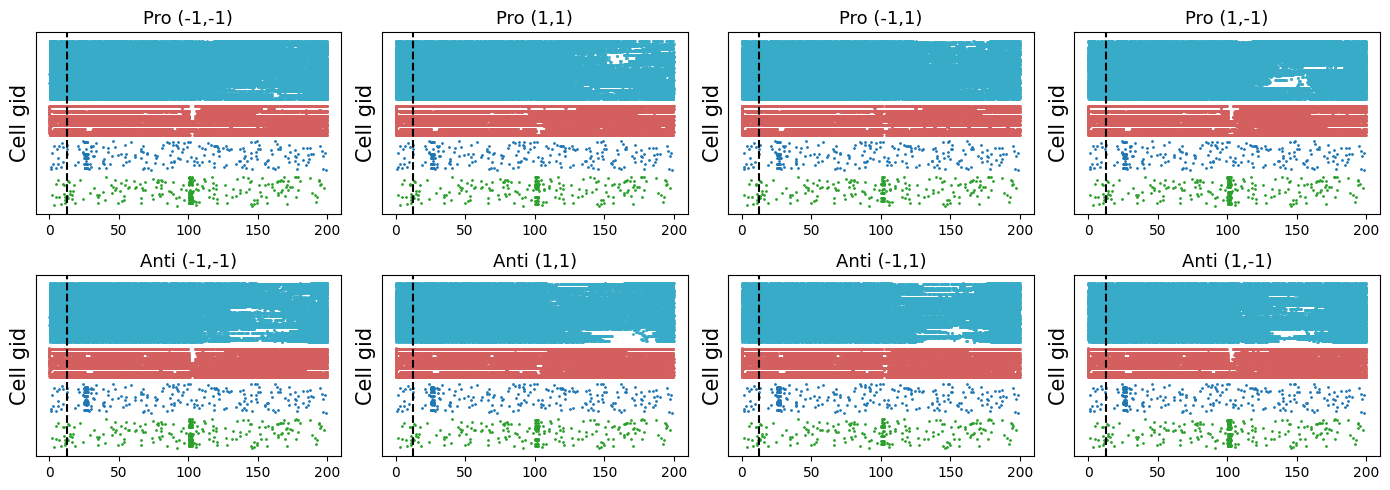

In [93]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10

    offset = num_cond * 0
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx + offset, :,:]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    # plt.xlim(0, time_vec[-1])
    plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()


    # plt.xlim(100, 106)

IndexError: index 32 is out of bounds for axis 0 with size 8

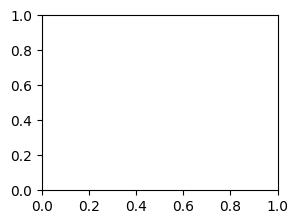

In [94]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10

    offset = num_cond * 4
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx + offset, :,:]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    # plt.xlim(0, time_vec[-1])
    plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()


    plt.xlim(100, 106)

In [70]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)



num_model_sims = 9

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_model_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_model_sims)])
model.fit(rate_fit, target_fit)

for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])


    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)



ValueError: Found input variables with inconsistent numbers of samples: [316040, 568872]

In [58]:
error_list

[]

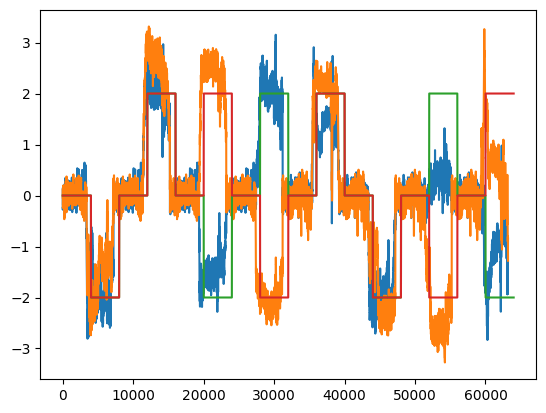

In [58]:
plt.plot(y_pred)
plt.plot(targets)